In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from deep_translator import GoogleTranslator
import unicodedata
import re 
import os

## 🟢 Helper Functions 

In [7]:
def normalize_unicode(text):
    edited = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii') 
    if edited.strip() == "":
        return text
    else:
        return edited

def Translate_Comment(text:str):
    translated_comment = GoogleTranslator().translate(text=text)
    if translated_comment:
        return normalize_unicode(translated_comment)
    return text

In [8]:
class Process_column:

    def __init__(self,Column_name:str,Dataset:pd.DataFrame):
        self.Column_name = Column_name
        self.Dataset = Dataset
    

    def Updeate_column(self,func):
        self.Dataset[self.Column_name] = self.Dataset[self.Column_name].apply(func=func)
        return self.Dataset
        

## 🟢 Reading Dataset

In [26]:
Path = os.getcwd() + "\\" + "Data"

In [10]:
df = pd.read_csv(f"{Path}\\all_combined.csv")
df.head()

,reviewId,content,score,app
0,1259786c-13cc-48b5-9bed-a5e8e21f410d,nice platform ♥️♥️,5,Facebook
1,bcd54507-bb4a-4a52-a9f7-4e78eb69a9e3,por favor dejame oculta sesion de reels,1,Facebook
2,83be76c0-1392-470c-8ad3-aa6424d6ae48,অনেক অনেক ধন্যবাদ,5,Facebook
3,3a0ea3c3-c35e-4faa-bcfe-7348890794a4,sus you,3,Facebook
4,a01a2c1c-ee8d-4113-8510-8b8f668dfab6,great app! no frills just thrill! 😍,5,Facebook


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  200000 non-null  object
 1   content   199982 non-null  object
 2   score     200000 non-null  int64 
 3   app       200000 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.1+ MB


In [12]:
df.dropna(inplace=True)

In [13]:
df["score"].value_counts()

score
5    121104
1     43877
4     16682
3      9975
2      8344
Name: count, dtype: int64

## 📍 Classes Distribution

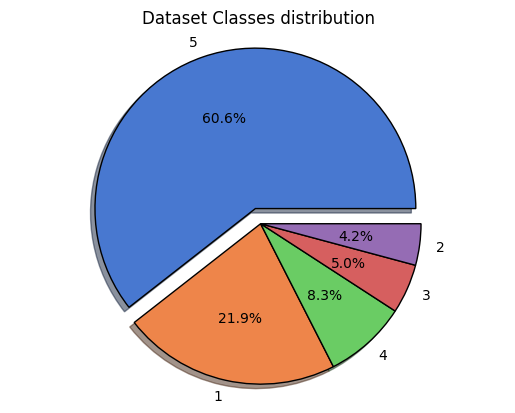

In [14]:
classes = df["score"].value_counts().to_dict()
plt.pie(x=classes.values(),labels=classes.keys(),wedgeprops = {'edgecolor': 'black'},autopct="%0.1f%%",shadow=True,colors=sns.color_palette("muted"),labeldistance=1.1,explode=[0.1,0,0,0,0])
plt.title("Dataset Classes distribution")
plt.axis("equal")
plt.show()

In [15]:
postive = [classes[i] for i in range(3,6)]
Negative = [classes[i] for i in range(1,3)]
print(f"Postive Class = {np.sum(postive):,.0f}")
print(f"Negative Class = {np.sum(Negative):,.0f}")

Postive Class = 147,761
Negative Class = 52,221


## 🟢 Extract *Non-English* Comments 

In [16]:
df["English"] = df["content"].apply(lambda x: bool(re.search(pattern=r"[a-zA-Z0-9]",string=x)))

In [17]:
data = df[df["English"] == False].loc[:,["content","score"]]
data.to_excel(f"{Path}\\Not_Translated.xlsx")

In [18]:
df["English"].value_counts()

English
True     193067
False      6915
Name: count, dtype: int64

## 📍 Delete *Non-English* Comments

In [19]:
df.drop(df[df["English"] == False].index,inplace=True)
df = df.iloc[:,1:3]

## ✅ Dataset After Translating to *English*

In [20]:
dataset = pd.read_excel(f"{Path}\\Translated.xlsx")
dataset.drop(columns=dataset.columns[0],inplace=True)
dataset

,content,score
0,Very very very much,5.0
1,😞😞😞,1.0
2,Good use of this social network,5.0
3,Very excellent,5.0
4,.,5.0
...,...,...
6910,The work of the people,5.0
6911,😍,5.0
6912,"Lately, the call signal has been very bad; the...",1.0
6913,Labu labu labu labu,5.0


## ✅ Merging 2 Dataset After Translating 

In [21]:
df = pd.DataFrame(np.vstack([df,dataset]),columns=df.columns)
df

,content,score
0,nice platform ♥️♥️,5
1,por favor dejame oculta sesion de reels,1
2,sus you,3
3,great app! no frills just thrill! 😍,5
4,good,5
...,...,...
199977,The work of the people,5.0
199978,😍,5.0
199979,"Lately, the call signal has been very bad; the...",1.0
199980,Labu labu labu labu,5.0


In [22]:
df.isna().sum()

content    98
score       2
dtype: int64

In [23]:
df.dropna(inplace=True)

In [24]:
df["English"] = df["content"].apply(lambda x: bool(re.search(pattern=r"[a-zA-Z0-9]",string=x)))
df[df["English"] == False]

,content,score,English
193068,😞😞😞,1.0,False
193071,.,5.0,False
193078,❤️‍🔥❤️‍🔥❤️‍🔥,5.0,False
193079,❤️‍🩹💗,5.0,False
193080,😊👌❤,5.0,False
...,...,...,...
199966,❤️❤️,5.0,False
199967,!!!!,5.0,False
199969,!!,5.0,False
199970,?,1.0,False


## 💾 Saving First Version of Cleaned Dataset

In [25]:
df.to_csv(f"{Path}\\Dataset.csv",index=False)

---

<h1 align="center"> ✅ The End of Dataset Handling Notebook </h1>


---